# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

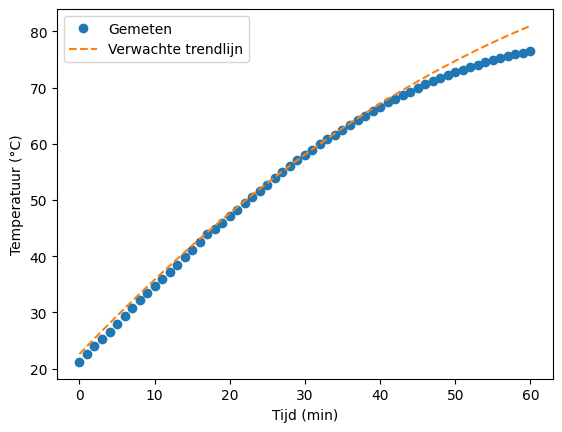

Energie voor opwarming van water: 105156.8 J
Energie voor verdamping van water: 40680.0 J
Totale toegevoerde energie: 145836.8 J


'\nVolgende keer gaan we het warmteverlies aan externe factoren verminderen voor een verbeterd\nexperiment. We kunnen daarnaast ook vaker dan een keer per minuut meten voor meer nauwkeurigheid.\n\n\n'

In [ ]:
data = np.loadtxt('tempmetingen46.csv.csv', delimiter=';', skiprows=1)
t = data[:,0]        
Temp = data[:,1]    


M_eind = (1274.9 - 820.8)/1000
M_start = (1292.9 - 820.8)/1000
M_verdampt = (M_start - M_eind)


c = 4180
L = 2.26e6


deltaT1 = Temp[1] - Temp[0]  
t1 = 60                      


P = (M_eind * c * deltaT1) / t1



# Rekening houden met het feit dat warmer water sneller verdampt
T_verwacht = []
for i, time_min in enumerate(t):

    factor = 1 - 0.01*i
    deltaT = (P*factor)/(M_eind*c) * 60
    if i == 0:
        T_verwacht.append(Temp[0]+deltaT)
    else:
        T_verwacht.append(T_verwacht[-1] + deltaT)

T_verwacht = np.array(T_verwacht)




plt.figure()
plt.plot(t, Temp, 'o', label='Gemeten')
plt.plot(t, T_verwacht, '--', label='Verwachte trendlijn')
plt.xlabel('Tijd (min)')
plt.ylabel('Temperatuur (°C)')
plt.legend()
plt.show()




# Vraag 2
deltaT_totaal = Temp[-1] - Temp[0]
Q_water = M_eind * c * deltaT_totaal


Q_verdamping = M_verdampt * L


Q_totaal = Q_water + Q_verdamping


print("Energie voor opwarming van water:", round(Q_water,1), "J")
print("Energie voor verdamping van water:", round(Q_verdamping,1), "J")
print("Totale toegevoerde energie:", round(Q_totaal,1), "J")


'''
Aannames:
1. Alle warmte van het verwarmingselement gaat op in water en verdamping
2. Geen warmteverlies aan de omgeving buiten verdamping
3. Verdamping is alleen van het water, niet van de beker
4. Soortelijke warmte en latente warmte constant over het temperatuurbereik
'''


# Vraag 3:


'''
Volgende keer gaan we het warmteverlies aan externe factoren verminderen voor een verbeterd
experiment. We kunnen daarnaast ook vaker dan een keer per minuut meten voor meer nauwkeurigheid.


'''
